# **Cross-Validation**

### **Motivation**

- Cross-validation is a method for splitting data into training and testing sets to evaluate model performance.
- Simple train-test splits require holding back a portion of data for testing, which limits training data availability.
- Cross-validation allows the model to be trained and evaluated on all available data through repeated splitting.

## **K-Fold Cross-Validation**

### **Procedure:**

1. Divide the dataset into K equal folds.
2. For each fold:
  - Use K-1 folds for training.
  - Use the remaining 1 fold for testing.
3. Repeat this process K times so that each fold serves once as the test set.
4. Compute an error metric for each fold.
5. Average the errors to obtain the mean error, representing estimated model performance.



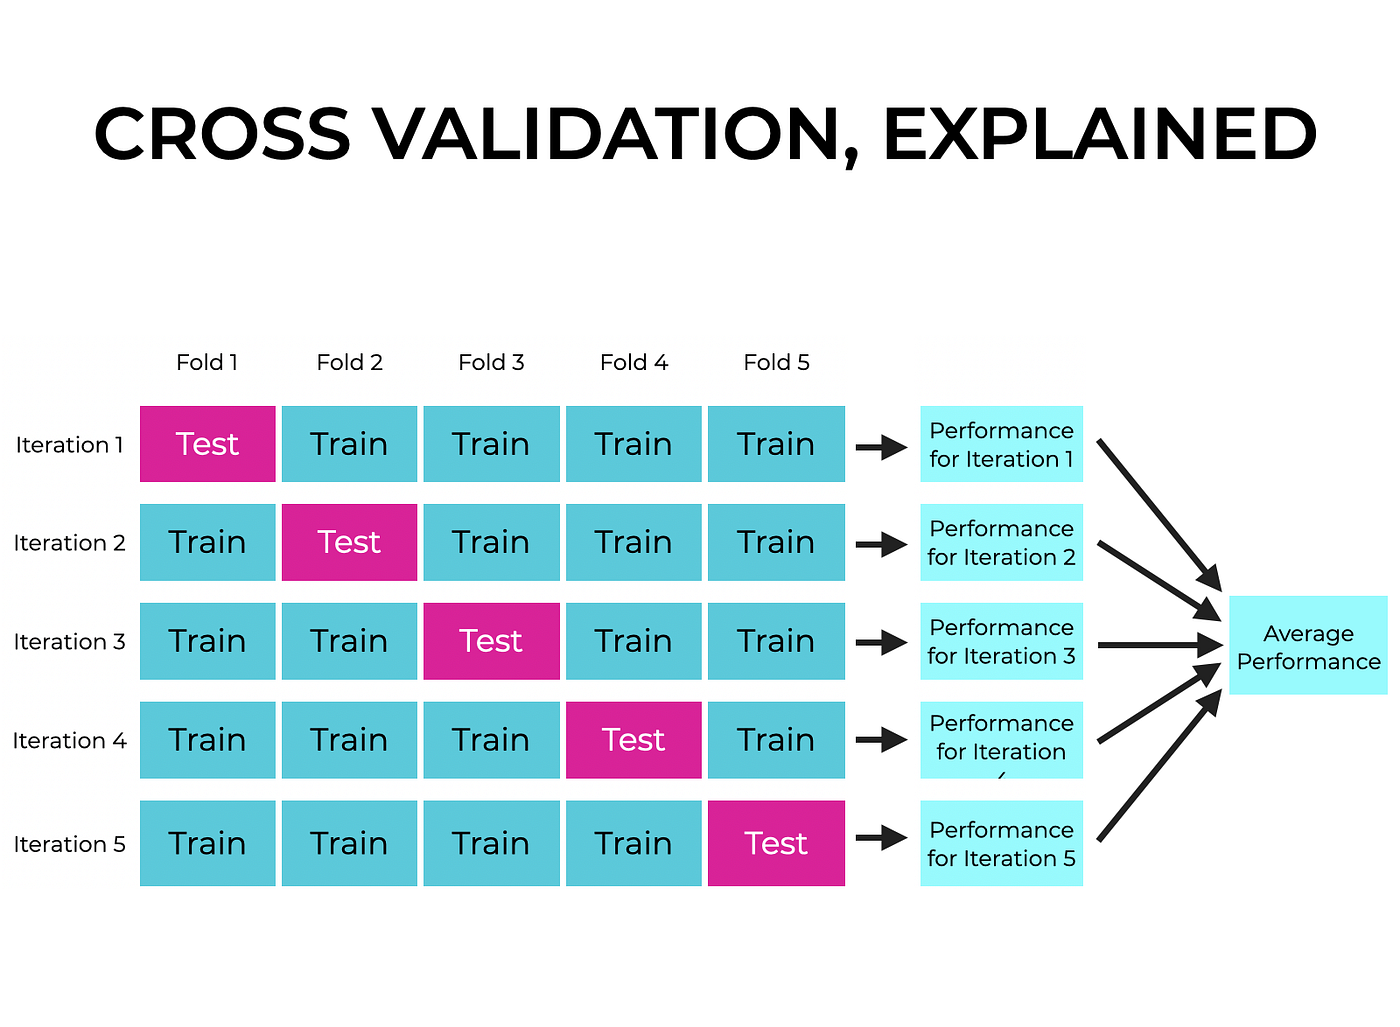

**Notes:**

- A typical choice is K = 10, resulting in test sets containing 10% of the data.
- **Leave-One-Out Cross-Validation (LOOCV):** each test set contains a single data point; highly accurate but computationally expensive.

#### **Advantages:**

- Evaluates the model on all data.
- Provides a robust estimate of performance across multiple splits.

#### **Disadvantages:**

- Increases computation time by a factor of K.

## **Hyperparameter Tuning and Data Leakage**

To avoid data leakage and ensure reliable performance evaluation, the best practice is indeed to:

- Extract a completely independent 'holdout test set' at the very beginning. This set remains untouched throughout the model development and hyperparameter tuning process.
- Apply cross-validation on the remaining data (which consists of the training and validation portions). Within each fold of the cross-validation, the data is further split into a 'training set' (for model fitting) and a 'validation set' (for hyperparameter evaluation).

This ensures that your final model's performance on the holdout test set is an unbiased estimate of its real-world performance, as it has never seen that data before.

- So, the dataset is divided into three parts:

| Dataset              | Purpose                                                         |
| -------------------- | --------------------------------------------------------------- |
| **Training set**     | Model fitting                                                   |
| **Validation set**   | Hyperparameter tuning and cross-validation                      |
| **Holdout test set** | Final performance evaluation (untouched during training/tuning) |

<br>

- Hyperparameters are optimized using the training and validation sets only.
- The holdout test set is used exclusively for reporting final performance metrics.


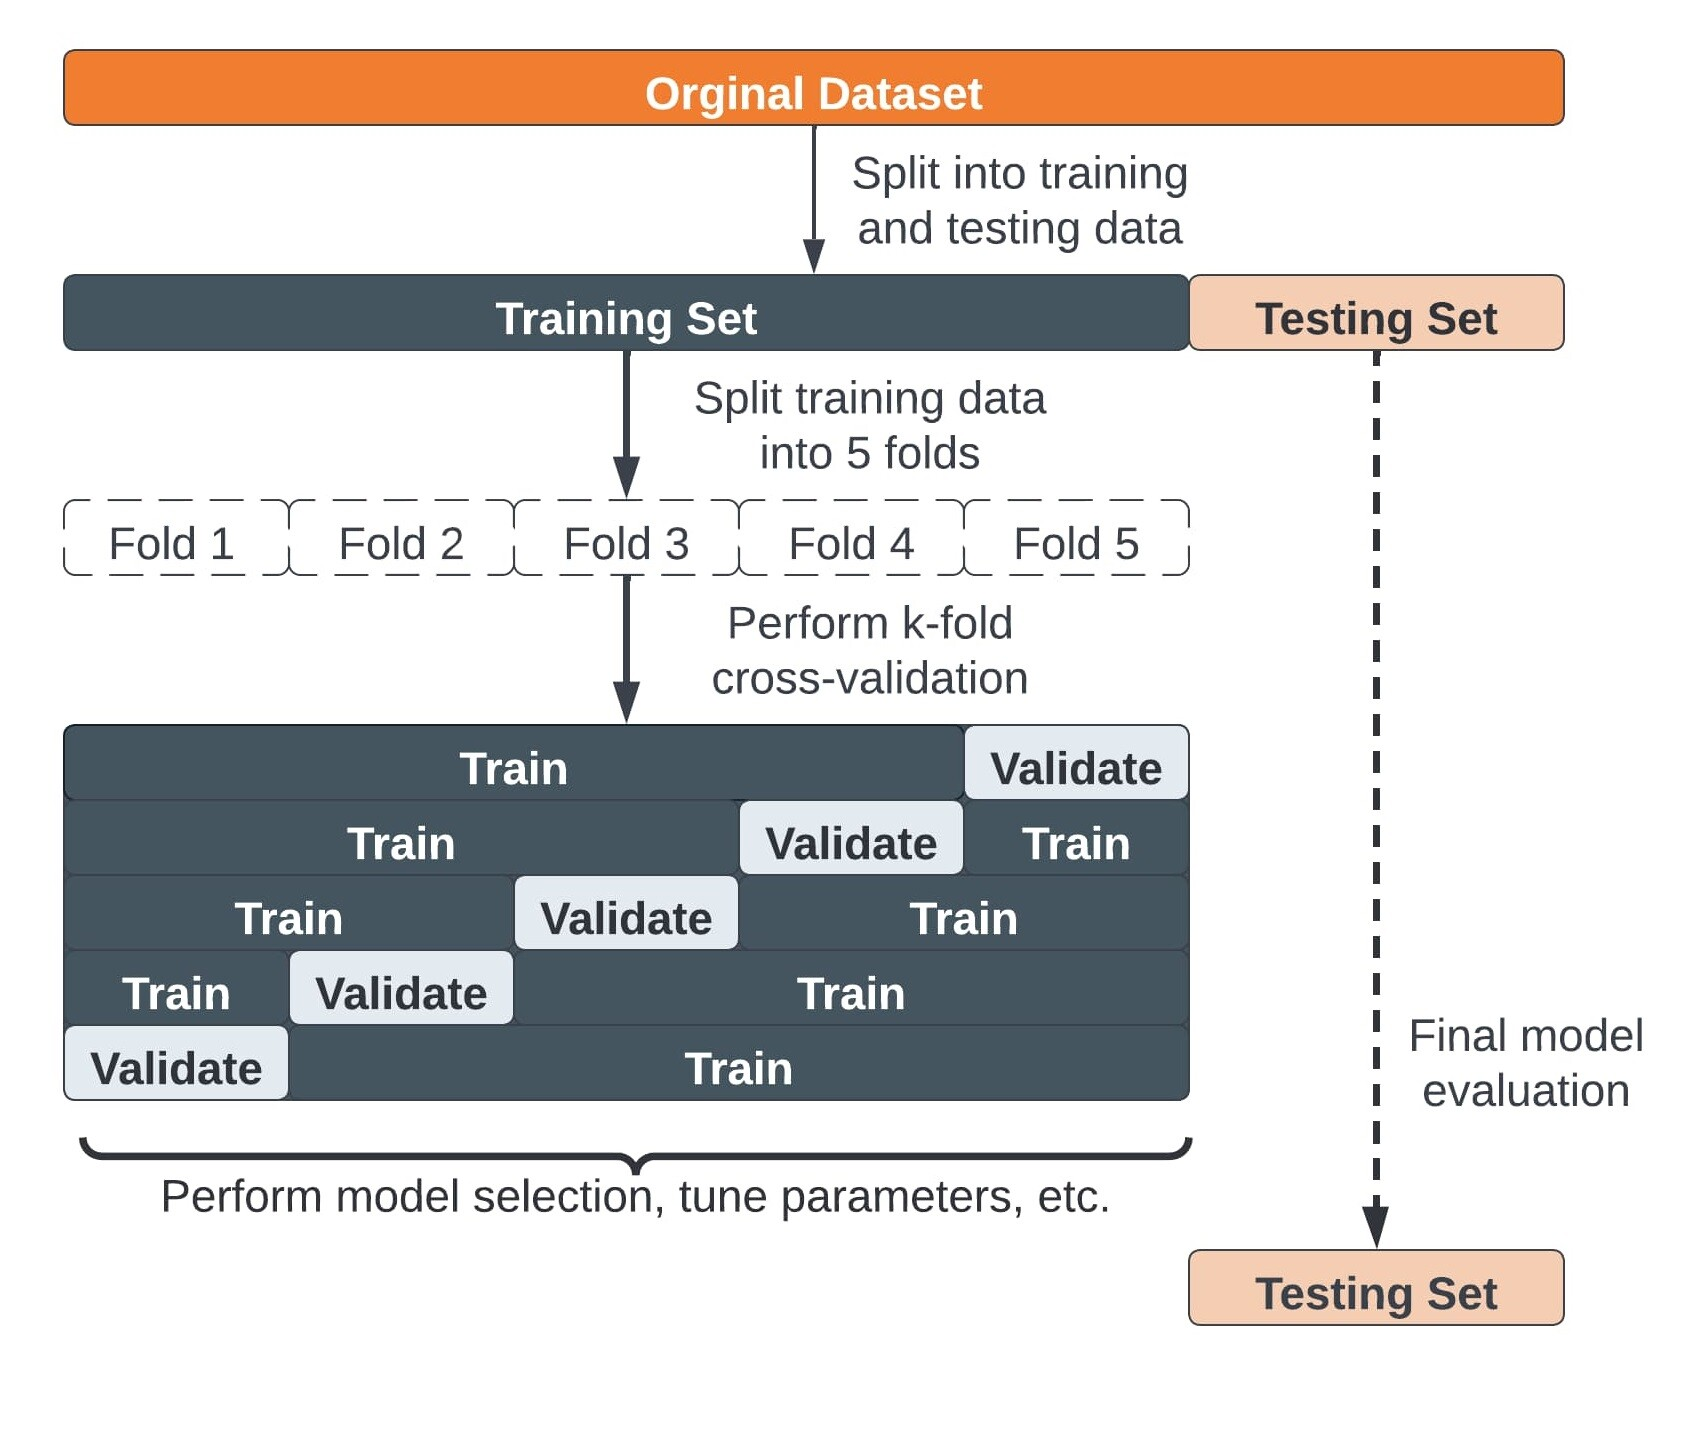

<br><br><br>

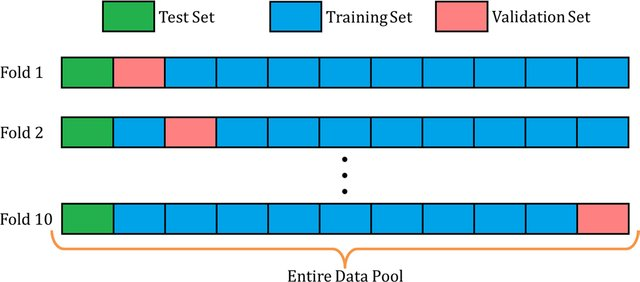

<br><br><br>

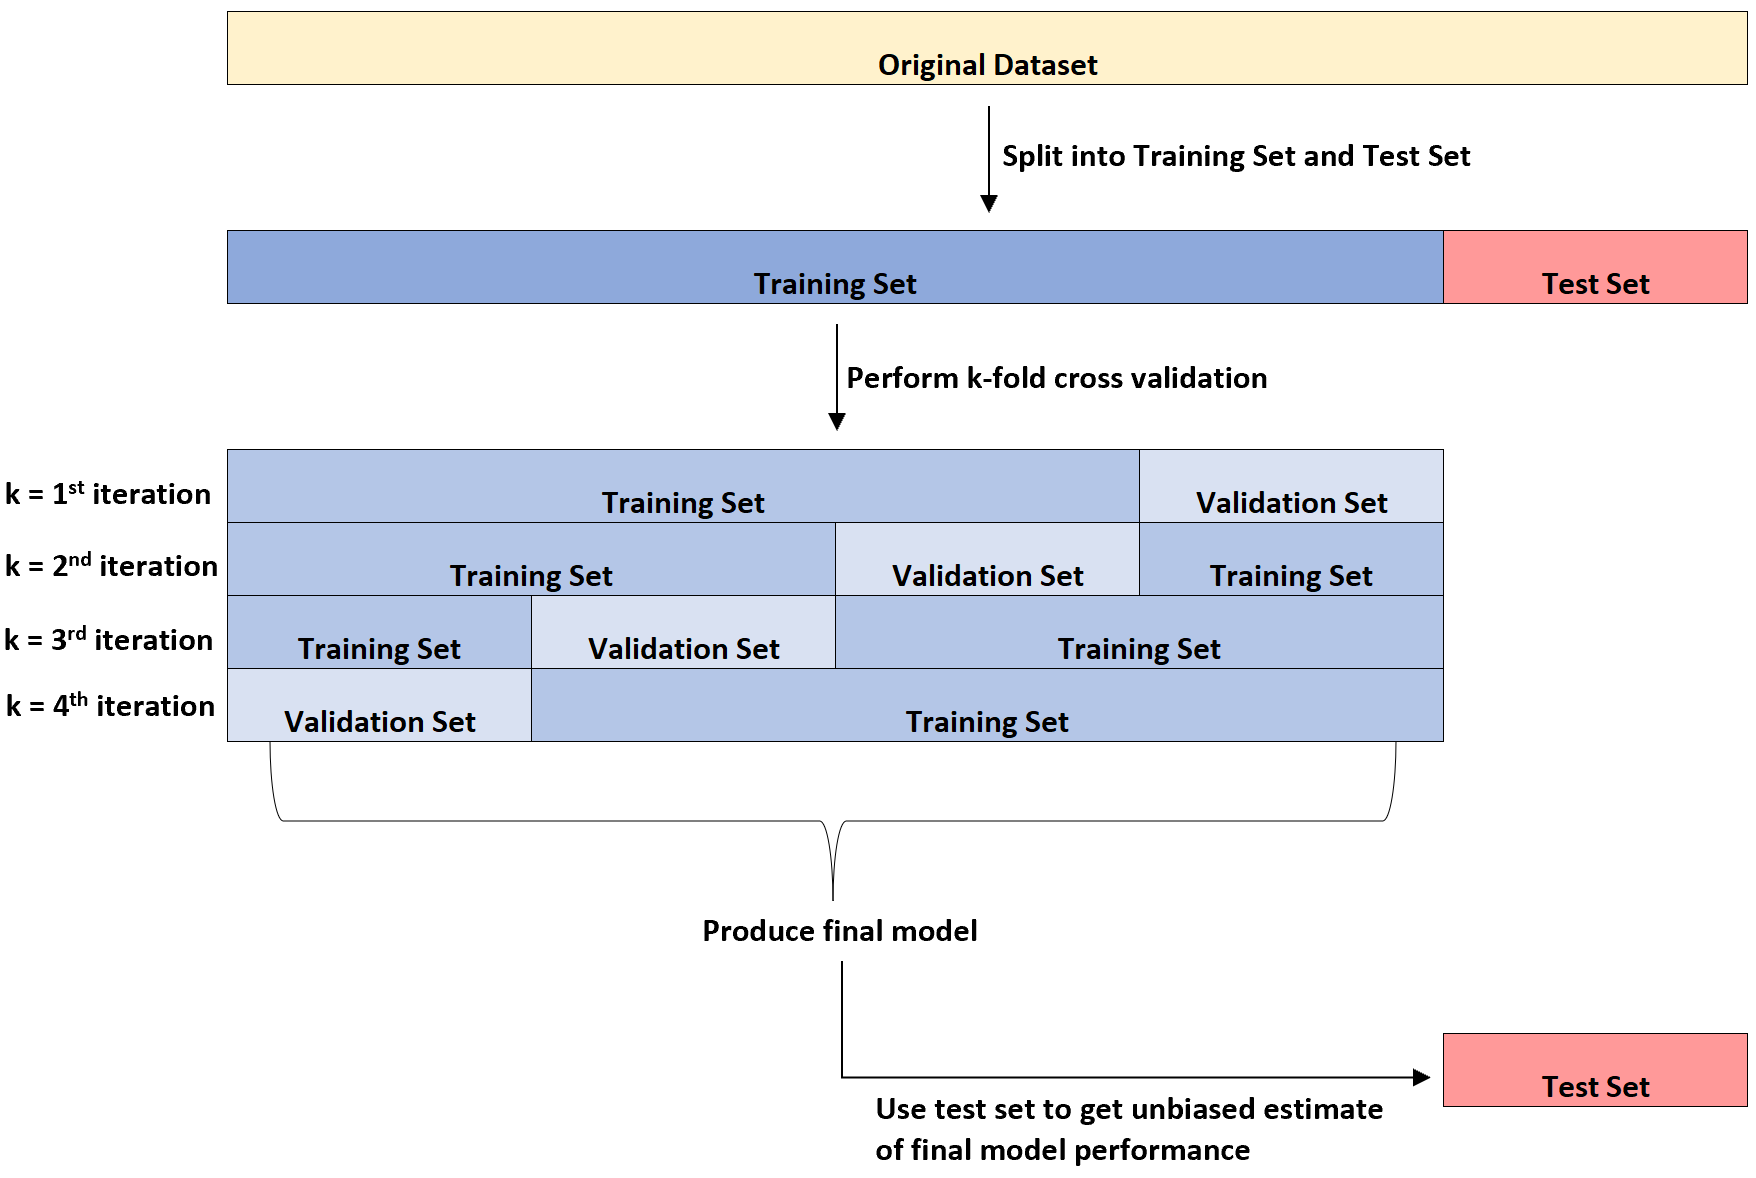

<br><br><br>

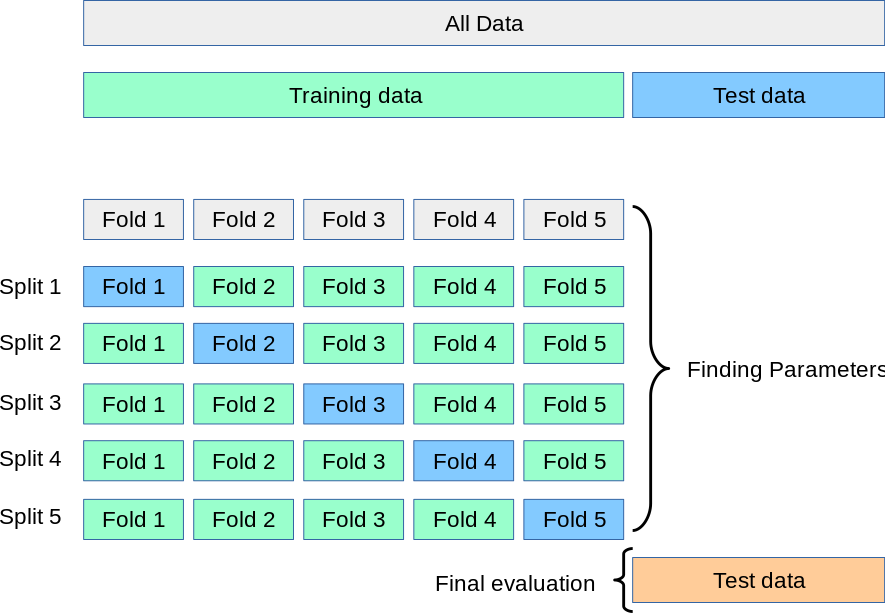

<br><br>

## **Cross-Validation in Scikit-learn**

The `cross_val_score` function in scikit-learn is a convenient way to perform cross-validation.

**Key Arguments:**
- `estimator`: The machine learning model (e.g., `LinearRegression()`, `LogisticRegression()`).
- `X`: The features (independent variables) of your dataset.
- `y`: The target variable (dependent variable) of your dataset.
- `cv`: Determines the cross-validation splitting strategy. It can be:
    - An integer, to specify the number of folds (e.g., `cv=5` for 5-fold cross-validation).
    - A CV splitter object (e.g., `KFold`, `StratifiedKFold`(for imbalanced datasets)).
    - An iterable yielding (train, test) splits.
- `scoring`: A string or a callable that determines how to evaluate the predictions on the test set. For regression, common options include:
    - `'r2'`: R-squared score, which measures the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher is better.
    - `'neg_mean_squared_error'`: Negative mean squared error. Lower (more negative) is better.
    - `'neg_mean_absolute_error'`: Negative mean absolute error. Lower (more negative) is better.
    - `'neg_root_mean_squared_error'`: Negative root mean squared error. Lower (more negative) is better.

<br>

**Why the Negative Sign for Error Metrics (`neg_mean_squared_error`)?**

Scikit-learn's `cross_val_score` (and other cross-validation utilities) always expects higher scores to be better. However, for error metrics like Mean Squared Error (MSE), a *lower* value indicates a *better* model.

To align error metrics with the

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Load the Advertising dataset
df_adv = pd.read_csv('/content/Advertising.csv')

# Define features (X_reg) and target (y_reg)
X_reg = df_adv[['TV', 'radio', 'newspaper']]
y_reg = df_adv['sales']

# Initialize a Linear Regression model
reg_model = LinearRegression()

# Perform 5-fold cross-validation
# For regression, 'neg_mean_squared_error' is a common scoring metric
cv_scores_reg = cross_val_score(reg_model, X_reg, y_reg, cv=5, scoring='neg_mean_squared_error')

# Convert negative mean squared error to positive RMSE for easier interpretation
rmse_scores = np.sqrt(-cv_scores_reg)

print(f"Cross-validation scores (Negative Mean Squared Error): {cv_scores_reg}")
print(f"Cross-validation scores (Root Mean Squared Error): {rmse_scores}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f}")
print(f"Standard deviation of RMSE scores: {np.std(rmse_scores):.4f}")

Cross-validation scores (Negative Mean Squared Error): [-3.1365399  -2.42566776 -1.58522508 -5.42615506 -2.79114519]
Cross-validation scores (Root Mean Squared Error): [1.77102792 1.55745554 1.25905722 2.32941088 1.67067208]
Mean RMSE: 1.7175
Standard deviation of RMSE scores: 0.3508
